<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  26/11/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

# **1. IMPORTAR LIBRERIAS**

In [2]:
# =====================================
# 1. Importar librerías necesarias
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense , Dropout
import tensorflow.keras.backend as K
import time
import os

2025-11-26 15:01:59.136299: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 15:01:59.145122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764187319.154324 2464754 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764187319.157041 2464754 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764187319.164494 2464754 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# **2. Lectura y exploración inicial del dataset**

In [4]:
# =====================================
# 2. Cargar el dataset base
# =====================================

PATH = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
file = "df_FINAL.csv"

filename =  os.path.join(PATH,file)
df       =  pd.read_csv(filename)

# Convertir columna de tiempo a formato datetime
df["Tiempo"] = pd.to_datetime(df["Tiempo"])
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204396 entries, 0 to 204395
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Tiempo       204396 non-null  datetime64[ns]
 1   Cintilacion  204396 non-null  float64       
 2   Azimuth      204396 non-null  float64       
 3   Elevacion    204396 non-null  float64       
 4   TEC          204396 non-null  float64       
 5   ROTEC        204396 non-null  float64       
 6   ROTI         204396 non-null  float64       
 7   Kp_Index     204396 non-null  float64       
 8   Dst_Index    204396 non-null  float64       
 9   ap_Index     204396 non-null  float64       
 10  f10.7_Index  204396 non-null  float64       
 11  AE_Index     204396 non-null  float64       
 12  S4           204396 non-null  float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 20.3 MB
None
               Tiempo  Cintilacion  Azimuth  Elevacion        TEC     ROT

In [6]:
# =====================================
# 3. Identificar días con cintilación
# =====================================
# Extraer solo la fecha
df["dias"] = df["Tiempo"].dt.date

# Número total de días en el dataset
print(f"Número total de días: {df['dias'].nunique()}")

# Filtrar días donde hubo cintilación (Cintilacion == 1)
df_con_cintilacion = df[df['Cintilacion'] == 1].copy()
df_con_cintilacion["Fecha"] = df_con_cintilacion["Tiempo"].dt.date

# Contar días únicos con cintilación
dias_unicos = pd.Series(df_con_cintilacion["Fecha"].unique())
print(f"Número de días con cintilación: {dias_unicos.nunique()}")

Número total de días: 148
Número de días con cintilación: 29


In [8]:
# DIA CON CINTILACION SI EN ALGÚN MINUTO DEL DIA S4>0.6
dias_cintilacion         = df.groupby("dias")["S4"].max()>0.6
dias_cintilacion         = dias_cintilacion.reset_index()
dias_cintilacion.columns = ["dias", "Cintilacion"]

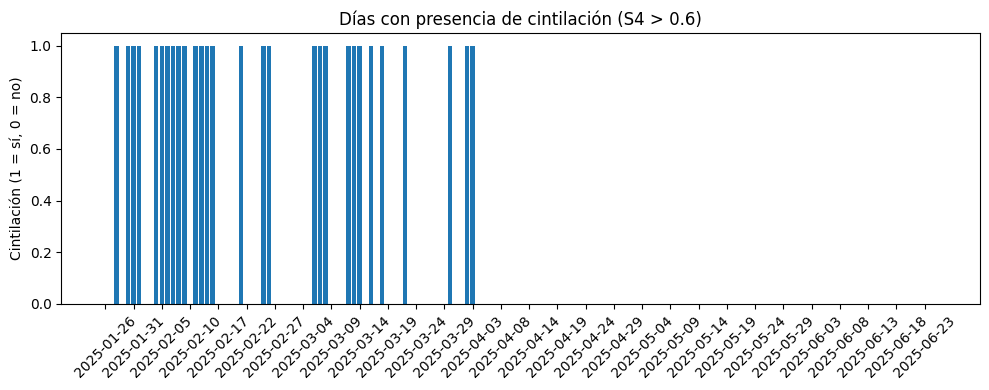

In [10]:
import matplotlib.pyplot as plt
# Configurar cada cuántas etiquetas mostrar
N = 5  # cada 5 días, ajusta según tu dataset
plt.figure(figsize=(10,4))
plt.bar(
    dias_cintilacion["dias"].astype(str),
    dias_cintilacion["Cintilacion"].astype(int)
)

plt.ylabel("Cintilación (1 = sí, 0 = no)")
plt.title("Días con presencia de cintilación (S4 > 0.6)")
# Mostrar etiqueta solo cada N días
labels = dias_cintilacion["dias"].astype(str)
plt.xticks(ticks=range(0, len(labels), N), labels=labels[::N], rotation=45)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# Asegurar formato datetime
df["Tiempo"] = pd.to_datetime(df["Tiempo"])
df["Fecha"] = df["Tiempo"].dt.date
df["Mes"] = df["Tiempo"].dt.to_period("M")  # AAAA-MM

# 1. Determinar si cada día tuvo cintilación (S4 > 0.6)
dias = df.groupby("Fecha")["S4"].max() > 0.6
dias = dias.reset_index()
dias.columns = ["Fecha", "Cintilacion"]

# Convertir True/False a 1/0
dias["Cintilacion"] = dias["Cintilacion"].astype(int)

# 2. Añadir columna Mes basada en la fecha
dias["Mes"] = pd.to_datetime(dias["Fecha"]).dt.to_period("M")

# 3. Tabla por mes: cuántos días con y sin cintilación
tabla_mensual = dias.groupby(["Mes", "Cintilacion"]).size().unstack(fill_value=0)

# Renombrar columnas
tabla_mensual.columns = ["Dias_sin_cintilacion", "Dias_con_cintilacion"]

# 4. Agregar columna total
tabla_mensual["Total_dias"] = tabla_mensual.sum(axis=1)

print(tabla_mensual)

         Dias_sin_cintilacion  Dias_con_cintilacion  Total_dias
Mes                                                            
2025-01                     3                     3           6
2025-02                    12                    14          26
2025-03                    21                    10          31
2025-04                    27                     2          29
2025-05                    31                     0          31
2025-06                    25                     0          25


In [14]:
import numpy as np

# --- 1. Asegurar que Tiempo es datetime ---
df["Tiempo"] = pd.to_datetime(df["Tiempo"])

# --- 2. Calcular minuto del día (0–1439) ---
df["minuto_del_dia"] = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute

# --- 3. Transformación cíclica en sin/cos ---
periodo = 1440  # minutos en un día

df["Hora_Sin"] = np.sin(2 * np.pi * df["minuto_del_dia"] / periodo)
df["Hora_Cos"] = np.cos(2 * np.pi * df["minuto_del_dia"] / periodo)

In [16]:
df.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4,dias,Fecha,Mes,minuto_del_dia,Hora_Sin,Hora_Cos
0,2025-01-26 00:35:00,0.0,189.0,31.0,69.258790,-0.020608,0.010838,3.0,-1.416667,2.0,165.4,29.083333,0.161,2025-01-26,2025-01-26,2025-01,35,0.152123,0.988362
1,2025-01-26 00:36:00,0.0,189.0,32.0,68.826191,-0.019268,0.010848,3.0,-1.400000,2.0,165.4,29.000000,0.122,2025-01-26,2025-01-26,2025-01,36,0.156434,0.987688
2,2025-01-26 00:37:00,0.0,197.0,32.0,68.393592,-0.017928,0.010858,3.0,-1.383333,2.0,165.4,28.916667,0.128,2025-01-26,2025-01-26,2025-01,37,0.160743,0.986996
3,2025-01-26 00:38:00,0.0,189.0,33.0,67.960993,-0.016589,0.010867,3.0,-1.366667,2.0,165.4,28.833333,0.106,2025-01-26,2025-01-26,2025-01,38,0.165048,0.986286
4,2025-01-26 00:39:00,0.0,196.0,32.0,67.528394,-0.015249,0.010877,3.0,-1.350000,2.0,165.4,28.750000,0.103,2025-01-26,2025-01-26,2025-01,39,0.169350,0.985556


In [20]:
# --- 1. Eliminar columna 'Fecha' o 'dias' ---
# nombre exacto de la columna que tengas:
df = df.drop(columns=["dias"], errors="ignore")

# --- 2. Mover columna S4 al final ---
col_s4 = df["S4"]                   # guardar temporalmente
df = df.drop(columns=["S4"])        # eliminarla
df["S4"] = col_s4                   # agregarla al final

In [22]:
df.head()

,Tiempo,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,Fecha,Mes,minuto_del_dia,Hora_Sin,Hora_Cos,S4
0,2025-01-26 00:35:00,0.0,189.0,31.0,69.258790,-0.020608,0.010838,3.0,-1.416667,2.0,165.4,29.083333,2025-01-26,2025-01,35,0.152123,0.988362,0.161
1,2025-01-26 00:36:00,0.0,189.0,32.0,68.826191,-0.019268,0.010848,3.0,-1.400000,2.0,165.4,29.000000,2025-01-26,2025-01,36,0.156434,0.987688,0.122
2,2025-01-26 00:37:00,0.0,197.0,32.0,68.393592,-0.017928,0.010858,3.0,-1.383333,2.0,165.4,28.916667,2025-01-26,2025-01,37,0.160743,0.986996,0.128
3,2025-01-26 00:38:00,0.0,189.0,33.0,67.960993,-0.016589,0.010867,3.0,-1.366667,2.0,165.4,28.833333,2025-01-26,2025-01,38,0.165048,0.986286,0.106
4,2025-01-26 00:39:00,0.0,196.0,32.0,67.528394,-0.015249,0.010877,3.0,-1.350000,2.0,165.4,28.750000,2025-01-26,2025-01,39,0.169350,0.985556,0.103


In [24]:
# --- 2. CONFIGURACIÓN CRÍTICA DEL ÍNDICE ---
# Convertimos 'Tiempo' a objeto datetime real
df['Tiempo'] = pd.to_datetime(df['Tiempo'])

# Ponemos el tiempo como índice (REQUISITO PARA LA FUNCIÓN DE VENTANAS)
df = df.set_index('Tiempo')
df = df.sort_index() # Siempre ordenar series temporales

print("Datos cargados. Rango de fechas:", df.index.min(), "a", df.index.max())

Datos cargados. Rango de fechas: 2025-01-26 00:35:00 a 2025-06-25 23:00:00


In [26]:
# ==============================================================================
# PASO 2: DIVISIÓN DE DATOS (TRAIN / VAL / TEST) POR DÍAS
# ==============================================================================
def dividir_por_dias(df):
    dias_unicos = np.sort(df['Fecha'].unique())
    n_dias = len(dias_unicos)
    
    # Porcentajes aproximados
    n_train = int(n_dias * 0.70)
    n_val = int(n_dias * 0.15)
    # El resto es Test
    
    dias_train = dias_unicos[:n_train]
    dias_val = dias_unicos[n_train : n_train + n_val]
    dias_test = dias_unicos[n_train + n_val:]
    
    # Filtrado
    train = df[df['Fecha'].isin(dias_train)].copy()
    val = df[df['Fecha'].isin(dias_val)].copy()
    test = df[df['Fecha'].isin(dias_test)].copy()
    
    print(f"✅ Paso 2 Completado.")
    print(f"   Train: {len(dias_train)} días | Val: {len(dias_val)} días | Test: {len(dias_test)} días")
    
    return train, val, test

# Ejecutamos Paso 2
train_df, val_df, test_df = dividir_por_dias(df)

✅ Paso 2 Completado.
   Train: 103 días | Val: 22 días | Test: 23 días


In [28]:
def analizar_distribucion_eventos(df, nombre_set, umbral_s4=0.6):
    """
    Cuenta cuántos días tienen al menos un minuto con S4 > umbral.
    """
    # 1. Obtenemos la lista total de días únicos en este set
    dias_totales = df['Fecha'].unique()
    num_dias_totales = len(dias_totales)
    
    # 2. Filtramos filas donde ocurrieron cintilaciones
    filas_con_evento = df[df['S4'] > umbral_s4]
    
    # 3. Identificamos a qué días pertenecen esas filas
    dias_con_evento = filas_con_evento['Fecha'].unique()
    num_dias_activos = len(dias_con_evento)
    
    # 4. Cálculo de porcentaje
    if num_dias_totales > 0:
        porcentaje = (num_dias_activos / num_dias_totales) * 100
    else:
        porcentaje = 0
        
    print(f"--- ANÁLISIS DEL SET: {nombre_set.upper()} ---")
    print(f"📅 Total de días:      {num_dias_totales}")
    print(f"⚡ Días con Cintilación: {num_dias_activos} (S4 > {umbral_s4})")
    print(f"📊 Porcentaje de actividad: {porcentaje:.2f}%")
    
    # Alerta visual si el set está "muerto"
    if num_dias_activos == 0:
        print(f"⚠️ PELIGRO: El set de {nombre_set} NO tiene eventos. El modelo no aprenderá/evaluará nada aquí.")
    else:
        print("✅ El set contiene eventos.")
    print("-" * 40)
    
    return dias_con_evento

# --- EJECUCIÓN ---

print("\n=== AUDITORÍA DE DATOS ===")
dias_activos_train = analizar_distribucion_eventos(train_df, "Entrenamiento (Train)")
dias_activos_val   = analizar_distribucion_eventos(val_df, "Validación (Val)")
dias_activos_test  = analizar_distribucion_eventos(test_df, "Prueba (Test)")


=== AUDITORÍA DE DATOS ===
--- ANÁLISIS DEL SET: ENTRENAMIENTO (TRAIN) ---
📅 Total de días:      103
⚡ Días con Cintilación: 29 (S4 > 0.6)
📊 Porcentaje de actividad: 28.16%
✅ El set contiene eventos.
----------------------------------------
--- ANÁLISIS DEL SET: VALIDACIÓN (VAL) ---
📅 Total de días:      22
⚡ Días con Cintilación: 0 (S4 > 0.6)
📊 Porcentaje de actividad: 0.00%
⚠️ PELIGRO: El set de Validación (Val) NO tiene eventos. El modelo no aprenderá/evaluará nada aquí.
----------------------------------------
--- ANÁLISIS DEL SET: PRUEBA (TEST) ---
📅 Total de días:      23
⚡ Días con Cintilación: 0 (S4 > 0.6)
📊 Porcentaje de actividad: 0.00%
⚠️ PELIGRO: El set de Prueba (Test) NO tiene eventos. El modelo no aprenderá/evaluará nada aquí.
----------------------------------------


Esta auditoría demuestra exactamente por qué no podíamos confiar en un corte cronológico simple.

**Los datos están concentrados:**

Todas las tormentas ocurrieron en la primera parte del año (probablemente en temporada de equinoccios) y la última parte (solsticios) fue tranquila.

Si entrenas así, el modelo aprenderá a detectar tormentas, pero cuando lo valides, como solo verá "días quietos", nunca sabrás si realmente aprendió o no.

**La Solución: División Estratificada por Días**

No podemos cortar el pastel en tres trozos seguidos. Tenemos que "barajar los días" (manteniendo intacto el orden de los minutos dentro de cada día) para asegurarnos de que los eventos raros (cintilaciones) se repartan equitativamente.

**Nuevo Paso 2: División Balanceada (Reemplaza tu función anterior)**

Este código separa los días "Activos" de los "Quietos" y reparte un poco de cada uno a los tres conjuntos.

In [30]:
from sklearn.model_selection import train_test_split

def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    """
    Divide el dataset asegurando que haya días con tormentas en Train, Val y Test.
    """
    # 1. Identificar Días Activos vs Días Quietos
    # Obtenemos parejas de (Fecha, Max_S4_del_dia)
    resumen_diario = df.groupby('Fecha')['S4'].max().reset_index()
    
    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    
    print(f"Total Días Activos encontrados: {len(dias_activos)}")
    print(f"Total Días Quietos encontrados: {len(dias_quietos)}")
    
    # 2. Repartir los Días ACTIVOS (aprox 70/15/15)
    # Primero separamos Train (70%) del resto (30%)
    activos_train, activos_temp = train_test_split(dias_activos, test_size=0.3, random_state=42)
    # Luego separamos ese resto en Val (50% del resto) y Test (50% del resto)
    activos_val, activos_test = train_test_split(activos_temp, test_size=0.5, random_state=42)
    
    # 3. Repartir los Días QUIETOS (misma lógica)
    quietos_train, quietos_temp = train_test_split(dias_quietos, test_size=0.3, random_state=42)
    quietos_val, quietos_test = train_test_split(quietos_temp, test_size=0.5, random_state=42)
    
    # 4. Combinar las listas
    lista_dias_train = np.concatenate([activos_train, quietos_train])
    lista_dias_val = np.concatenate([activos_val, quietos_val])
    lista_dias_test = np.concatenate([activos_test, quietos_test])
    
    # 5. Crear los DataFrames Finales
    # Ordenamos por fecha para mantener la lógica temporal interna
    train = df[df['Fecha'].isin(lista_dias_train)].sort_index()
    val = df[df['Fecha'].isin(lista_dias_val)].sort_index()
    test = df[df['Fecha'].isin(lista_dias_test)].sort_index()
    
    return train, val, test

# --- EJECUTAR LA CORRECCIÓN ---

print("Re-calculando la división de datos...")
# Usamos el df_completo que cargamos en el Paso 1
train_df, val_df, test_df = dividir_estratificado_por_dias(df, umbral_s4=0.6)

# --- RE-AUDITORÍA PARA CONFIRMAR ---
print("\n=== NUEVA AUDITORÍA DE DATOS ===")
analizar_distribucion_eventos(train_df, "Entrenamiento (Train)")
analizar_distribucion_eventos(val_df, "Validación (Val)")
analizar_distribucion_eventos(test_df, "Prueba (Test)")

Re-calculando la división de datos...
Total Días Activos encontrados: 29
Total Días Quietos encontrados: 119

=== NUEVA AUDITORÍA DE DATOS ===
--- ANÁLISIS DEL SET: ENTRENAMIENTO (TRAIN) ---
📅 Total de días:      103
⚡ Días con Cintilación: 20 (S4 > 0.6)
📊 Porcentaje de actividad: 19.42%
✅ El set contiene eventos.
----------------------------------------
--- ANÁLISIS DEL SET: VALIDACIÓN (VAL) ---
📅 Total de días:      22
⚡ Días con Cintilación: 4 (S4 > 0.6)
📊 Porcentaje de actividad: 18.18%
✅ El set contiene eventos.
----------------------------------------
--- ANÁLISIS DEL SET: PRUEBA (TEST) ---
📅 Total de días:      23
⚡ Días con Cintilación: 5 (S4 > 0.6)
📊 Porcentaje de actividad: 21.74%
✅ El set contiene eventos.
----------------------------------------


array([datetime.date(2025, 1, 28), datetime.date(2025, 2, 9),
       datetime.date(2025, 2, 26), datetime.date(2025, 3, 30),
       datetime.date(2025, 4, 2)], dtype=object)

**Qué esperar ahora?**

Con este cambio, tus resultados de auditoría deberían verse similares a esto:

- Train: ~20-21 días activos.

- Val: ~4-5 días activos.

- Test: ~4-5 días activos.

**¿Es válido "barajar" los días?**

En series temporales estrictas (como predecir el valor de una acción en la bolsa minuto a minuto para siempre), barajar es peligroso. PERO, en física ionosférica con datos discontinuos:

1. La correlación entre lo que pasó el "Martes 5" y el "Jueves 20" es baja (a menos que sea una tormenta solar continua de varios días).

2. La correlación importante es la de minuto a minuto dentro de la misma noche.

3. Al usar train_test_split sobre la lista de fechas, estamos moviendo bloques de 24 horas completos. La LSTM seguirá viendo la evolución completa de la noche (atardecer -> cintilación -> amanecer) sin interrupciones.

# **1. El "Efecto" de Hora_Sin y Hora_Cos (Desmitificado)**
Imagina que le damos a la LSTM la hora como un número simple del 0 al 23.
* A las 23:00, la red recibe un valor alto (23).
* A las 00:00 (una hora después), recibe un valor bajísimo (0).

Para la red, eso es un precipicio. Matemáticamente, piensa que hubo un cambio brusco, como si la temperatura hubiera caído de golpe. Esto rompe la continuidad temporal y afecta su memoria interna ($h_t$), justo en el momento más crítico para las cintilaciones (la medianoche).

**La Solución Geométrica**
Al usar **Sin y Cos**, transformamos el tiempo lineal (una línea recta cortada) en un Círculo (Reloj de 24h).
Mira esta tabla de valores reales. Observamos cómo "bailan" los números:

|Hora Real | Minuto del día| Hora_Sin (Eje Y) |Hora_Cos (Eje X)|Interpretación|
|----------|---------------|------------------|----------------|--------------|
|00:00|0|0.0|1.0|Punto más alto del círculo|
|06:00|360|1.0|0.0|Derecha extrema|
|12:00|720|0.0|-1.0|Punto más bajo|
|18:00|1080|-1.0|0.0|Izquierda extrema|
|23:59|1439|-0.004|0.999|Casi idéntico a las 00:00|

El Efecto:
1. **Suavidad:** Fíjate en las 23:59 y las 00:00. En Sin/Cos, los valores son casi idénticos. La LSTM entiende que son vecinos.
2. **Unicidad:** Si solo usaras Seno, las 06:00 (1.0) se confundirían con otro punto. Al tener el par (Sin, Cos), cada minuto del día tiene una "huella digital" (coordenada) única.

# **NORMALIZACION**

In [32]:
train_df.head()

,Cintilacion,Azimuth,Elevacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,Fecha,Mes,minuto_del_dia,Hora_Sin,Hora_Cos,S4
Tiempo,,,,,,,,,,,,,,,,,
2025-01-27 00:01:00,0.0,224.0,41.0,75.257259,0.014589,0.015611,0.0,-0.983333,0.0,157.6,27.916667,2025-01-27,2025-01,1,0.004363,0.999990,0.092
2025-01-27 00:02:00,0.0,225.0,42.0,74.749186,0.014245,0.015742,0.0,-0.966667,0.0,157.6,27.833333,2025-01-27,2025-01,2,0.008727,0.999962,0.087
2025-01-27 00:03:00,0.0,141.0,51.0,74.241113,0.013901,0.015874,0.0,-0.950000,0.0,157.6,27.750000,2025-01-27,2025-01,3,0.013090,0.999914,0.105
2025-01-27 00:04:00,0.0,140.0,51.0,73.733040,0.013556,0.016006,0.0,-0.933333,0.0,157.6,27.666667,2025-01-27,2025-01,4,0.017452,0.999848,0.105
2025-01-27 00:05:00,0.0,139.0,52.0,73.224967,0.013212,0.016137,0.0,-0.916667,0.0,157.6,27.583333,2025-01-27,2025-01,5,0.021815,0.999762,0.089


Basado en las columnas que tienes en tu train_df, la lista correcta de features_cols debe contener solo las variables numéricas que aportan información física o temporal para predecir el futuro.

Debes excluir fechas (strings), índices redundantes o variables que no aportan valor predictivo (como el Azimut, a menos que estés modelando un satélite específico muy estricto).

Aquí tenemos  la selección recomendada para tu caso:

In [34]:
# Selección de características (Features)
features_cols = [
    'TEC',         # FÍSICA: Densidad de electrones
    'ROTI',        # FÍSICA: La medida de irregularidad (Precursor clave)
    'Kp_Index',    # GEOMAGNETISMO: Estado global (cada 3 horas)
    'Dst_Index',   # GEOMAGNETISMO: ¡Muy importante! Reacciona rápido a tormentas
    'AE_Index',     # Actividad auroral/subtormentas (ALTA frecuencia - Minuto a minuto)
    'f10.7_Index', # SOLAR: Flujo solar (ruido de fondo/ionización base)
    'Hora_Sin',    # TIEMPO: Ciclo diario (continuidad medianoche)
    'Hora_Cos',    # TIEMPO: Ciclo diario (unicidad)
    'S4',          # TARGET: El valor histórico es el mejor predictor del futuro
]

**¿Por qué elegí estas y descarté las otras?**
1. S4, TEC, ROTI: Son el núcleo físico. ROTEC suele ser redundante si ya tienes ROTI (que es el estándar), así que mejor usar solo uno para no confundir a la red con datos repetidos (multicolinealidad).

2. Kp_Index y Dst_Index: Tienes ambos. Úsalos. El Dst es excelente porque suele tener resolución horaria y mide la intensidad de la corriente de anillo, vital para cintilaciones ecuatoriales.

3. f10.7_Index: Ayuda al modelo a distinguir si estamos en un día de alta actividad solar general o baja.

4. Hora_Sin / Hora_Cos: Indispensables para que la red sepa si es de noche o de día.

**Qué descarté y por qué?**
- Tiempo, Fecha, Mes: La red neuronal no sabe leer fechas, solo números. El tiempo ya está codificado en el Seno/Coseno.

- Azimuth, Elevacion: Generalmente se excluyen en modelos generales. ¿Por qué? Porque si tu serie temporal mezcla datos de varios satélites, estos valores saltarán locamente y meterán ruido. Si es un solo satélite, la física (TEC/ROTI) es más importante que la posición geométrica.

- Cintilacion: Parece ser una bandera (0.0) o un valor redundante. Si tu objetivo es predecir la magnitud S4, usa S4.

- minuto_del_dia: Ya está representado mejor por Sin/Cos.

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# -----------------------------------------------------------------------------
# CONFIGURACIÓN
# -----------------------------------------------------------------------------
# Definimos exactamente qué columnas entran al modelo
features_cols = ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index','AE_Index','f10.7_Index', 'Hora_Sin', 'Hora_Cos']

# Inicializamos el escalador para que todo quede entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))

# -----------------------------------------------------------------------------
# FUNCIÓN DE NORMALIZACIÓN SEGURA
# -----------------------------------------------------------------------------
def escalar_preservando_indices(df_subset, scaler, cols, is_train=False):
    """
    Normaliza un DataFrame pero devuelve otro DataFrame con el mismo índice temporal.
    """
    if df_subset.empty: 
        return df_subset
    
    # IMPORTANTE: Solo 'aprendemos' (fit) los máximos y mínimos con el set de TRAIN
    if is_train:
        scaler.fit(df_subset[cols])
    
    # Transformamos los datos (Matriz numpy)
    scaled_values = scaler.transform(df_subset[cols])
    
    # Reconstruimos el DataFrame pegándole el índice original
    df_scaled = pd.DataFrame(
        scaled_values, 
        columns=cols, 
        index=df_subset.index 
    )
    
    # Añadimos la columna 'Fecha' por si la necesitamos para depurar, 
    # aunque para la LSTM numérica ya no sirve, es útil para nosotros.
    df_scaled['Fecha'] = df_subset['Fecha'].values
    
    return df_scaled

# -----------------------------------------------------------------------------
# EJECUCIÓN DEL PASO 3
# -----------------------------------------------------------------------------
print("Iniciando normalización...")

# 1. Definir las columnas
features_cols = [
    'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index','AE_Index','f10.7_Index', 
    'Hora_Sin', 'Hora_Cos'
]

# 2.1 Normalizamos TRAIN (Aquí aprende el scaler)
train_scaled = escalar_preservando_indices(train_df, scaler, features_cols, is_train=True)

# 2.2 Normalizamos VAL y TEST (Usando lo aprendido en Train)
val_scaled = escalar_preservando_indices(val_df, scaler, features_cols, is_train=False)
test_scaled = escalar_preservando_indices(test_df, scaler, features_cols, is_train=False)

# -----------------------------------------------------------------------------
# 3 VERIFICACIÓN
# -----------------------------------------------------------------------------
print("\n✅ Normalización completada.")
print(f"Rango de S4 en Train (Original): {train_df['S4'].min():.4f} a {train_df['S4'].max():.4f}")
print(f"Rango de S4 en Train (Escalado): {train_scaled['S4'].min():.4f} a {train_scaled['S4'].max():.4f}")

# Chequeo rápido de Seno/Coseno escalados
# Nota: Como MinMaxScaler va de 0 a 1, el Seno (-1 a 1) se transformará: -1 -> 0, 0 -> 0.5, 1 -> 1.
print("\nEjemplo de datos escalados (Primeras 3 filas de Train):")
print(train_scaled[['Hora_Sin', 'Hora_Cos', 'S4']].head(3))

Iniciando normalización...

✅ Normalización completada.
Rango de S4 en Train (Original): 0.0380 a 1.2930
Rango de S4 en Train (Escalado): 0.0000 a 1.0000

Ejemplo de datos escalados (Primeras 3 filas de Train):
                     Hora_Sin  Hora_Cos        S4
Tiempo                                           
2025-01-27 00:01:00  0.502182  1.000000  0.043028
2025-01-27 00:02:00  0.504363  0.999986  0.039044
2025-01-27 00:03:00  0.506545  0.999962  0.053386


## **El Concepto: Ventana Deslizante con "Vigilante de Tiempo"**

Imagina que tienes una cámara de video que graba 60 minutos del pasado para intentar adivinar qué pasará 20 minutos en el futuro.

El problema de tus datos es que la "grabación" no es continua. A veces la cámara se apaga (el GPS pierde señal o se reinicia).

* Sin control de Gaps: Si cortas ciegamente, podrías unir el minuto 14:00 con el minuto 18:00 y decirle a la red: "Mira, esto pasó un minuto después". Eso confundiría fatalmente a la física del modelo.

* Con control de Gaps: Nuestro código verificará el código de tiempo (Timestamp) de cada fotograma. Si detecta que falta aunque sea un minuto en la secuencia, tira esa ventana a la basura. Solo aceptamos secuencias perfectas.

Este es el paso donde la magia ocurre, pero también donde debemos ser más rigurosos. Vamos a transformar tus tablas de Excel (2D) en bloques de "video" (3D) para que la Red Neuronal pueda ver la película de lo que pasó antes.

In [38]:
import numpy as np
import pandas as pd

def crear_dataset_lstm_con_gaps(df, cols_input, col_target, lookback=60, horizon=20):
    """
    Genera tensores X e y verificando rigurosamente la continuidad del tiempo.
    
    Args:
        df: DataFrame normalizado con DatetimeIndex.
        cols_input: Lista de columnas para usar como predictores (Features).
        col_target: Nombre de la columna objetivo (S4).
        lookback: Tamaño de la ventana hacia atrás (minutos).
        horizon: Qué tan lejos queremos predecir (minutos).
        
    Returns:
        X: Tensor 3D (Muestras, Pasos de Tiempo, Features)
        y: Array 1D (Muestras,) - Valor objetivo
    """
    
    # 1. Preparación de datos crudos para velocidad
    # Convertimos el DataFrame a matriz NumPy (mucho más rápido que iterar pandas)
    data_values = df[cols_input].values  
    target_values = df[col_target].values
    
    # Extraemos los tiempos para poder hacer las restas
    timestamps = df.index.to_series().values
    
    X, y = [], []
    
    # 2. Bucle Principal (El "Deslizamiento")
    # Empezamos en 'lookback' porque necesitamos 60 mins atrás
    # Terminamos en len - horizon porque necesitamos 20 mins adelante
    for i in range(lookback, len(df) - horizon):
        
        # --- EL VIGILANTE DE TIEMPO (GAP CONTROL) ---
        
        # Tomamos los tiempos clave
        t_actual = timestamps[i]                 # El "Ahora" (t)
        t_inicio = timestamps[i - lookback]      # El inicio de la ventana (t - 60)
        t_futuro = timestamps[i + horizon]       # El objetivo (t + 20)
        
        # Calculamos diferencias en MINUTOS
        # (np.timedelta64 lo convierte a milisegundos, por eso dividimos por 60000)
        diff_atras = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        diff_adelante = (t_futuro - t_actual) / np.timedelta64(1, 'm')
        
        # CONDICIÓN 1: ¿La ventana de entrada es continua?
        # Debe haber exactamente 60 minutos de diferencia. 
        # Si hay 61 o 300, significa que hubo un hueco.
        if diff_atras != lookback:
            continue # Saltamos esta muestra, está rota.
            
        # CONDICIÓN 2: ¿Tenemos el futuro exacto?
        # Debe haber exactamente 20 minutos hasta el target.
        if diff_adelante != horizon:
            continue # Saltamos, no sabemos qué pasó 20 mins después.
            
        # --- SI PASA LAS PRUEBAS, GUARDAMOS ---
        
        # Cortamos la rebanada de datos (Slicing)
        # Desde (i - 60) hasta i
        ventana = data_values[i-lookback : i] 
        
        # Tomamos el valor objetivo en (i + 20)
        objetivo = target_values[i + horizon]
        
        X.append(ventana)
        y.append(objetivo)

    return np.array(X), np.array(y)

# -----------------------------------------------------------------------------
# EJECUCIÓN CON TUS DATOS ESCALADOS
# -----------------------------------------------------------------------------

# Configuración (Asegúrate de que features_cols tenga tus 9 variables)
LOOKBACK = 60   # Ventana de historia
HORIZON = 20    # Pronóstico futuro

print(f"Generando ventanas con: Lookback={LOOKBACK} min, Horizon={HORIZON} min...")
print(f"Features ({len(features_cols)}): {features_cols}")

# 1. Generar Train
X_train, y_train = crear_dataset_lstm_con_gaps(train_scaled, features_cols, 'S4', LOOKBACK, HORIZON)
print(f"\n✅ TRAIN generado. Muestras válidas: {X_train.shape[0]}")

# 2. Generar Val
X_val, y_val = crear_dataset_lstm_con_gaps(val_scaled, features_cols, 'S4', LOOKBACK, HORIZON)
print(f"✅ VAL generado.   Muestras válidas: {X_val.shape[0]}")

# 3. Generar Test
X_test, y_test = crear_dataset_lstm_con_gaps(test_scaled, features_cols, 'S4', LOOKBACK, HORIZON)
print(f"✅ TEST generado.  Muestras válidas: {X_test.shape[0]}")

# -----------------------------------------------------------------------------
# VERIFICACIÓN DE DIMENSIONES (IMPORTANTE)
# -----------------------------------------------------------------------------
print("\n--- DIMENSIONES FINALES (Tensor Shapes) ---")
print(f"X_train: {X_train.shape}  -> (Muestras, 60 pasos, 9 variables)")
print(f"y_train: {y_train.shape}  -> (Muestras, 1 variable)")
print("------------------------------------------------")
print(f"Muestras de Validación: {X_val.shape[0]}")
print(f"Muestras de Test:       {X_test.shape[0]}")

Generando ventanas con: Lookback=60 min, Horizon=20 min...
Features (9): ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']

✅ TRAIN generado. Muestras válidas: 132431
✅ VAL generado.   Muestras válidas: 28699
✅ TEST generado.  Muestras válidas: 30096

--- DIMENSIONES FINALES (Tensor Shapes) ---
X_train: (132431, 60, 9)  -> (Muestras, 60 pasos, 9 variables)
y_train: (132431,)  -> (Muestras, 1 variable)
------------------------------------------------
Muestras de Validación: 28699
Muestras de Test:       30096


#**Explicación del Detalle "Técnico"**

1. timestamps = df.index.to_series().values:

    * Extraemos el índice de tiempo y lo convertimos a un array de NumPy. Esto es crucial porque trabajar con índices de Pandas dentro de un bucle for de millones de filas es lento. NumPy es instantáneo.

2. np.timedelta64(1, 'm'):

    * Cuando restas dos fechas en NumPy (t_actual - t_inicio), el resultado sale en una unidad extraña (nanosegundos o milisegundos). Al dividir por "1 minuto" (1, 'm'), obtenemos un número limpio: 60.0.

    * La condición if diff_atras != lookback es estricta. Si el resultado es 61.0, se descarta. Esto asegura integridad total.

3. data_values[i-lookback : i]:

    * Esto crea la matriz 2D de (60 filas, 9 columnas).

    * Al hacer X.append, vamos apilando estas matrices como si fueran hojas de papel, creando finalmente el bloque 3D.

# **Paso 5: Construcción y Entrenamiento**

Ahora vamos a construir el cerebro (la Red LSTM) y enseñarle a detectar cintilaciones.Aquí enfrentamos el reto que discutimos al principio: El Desbalance. Como la mayoría de tus datos son días tranquilos, si usamos un error normal, la red aprenderá a predecir siempre "cero" y tendrá un error bajísimo, pero será inútil.Usaremos la Función de Pérdida Ponderada (Weighted Loss).Concepto Clave: El Umbral NormalizadoTú sabes que un evento es $S_4 > 0.6$. Pero tus datos y_train ahora están entre 0 y 1.Necesitamos convertir ese $0.6$ real al "idioma" del escalador.Si tu $S_4$ máximo histórico fue 2.0, entonces el umbral para la red será $0.6 / 2.0 = 0.3$.Aquí tienes el código completo para construir, compilar y entrenar el modelo.

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

tf.keras.backend.clear_session()


# -----------------------------------------------------------------------------
# 1. CALCULAR EL UMBRAL EN ESCALA NORMALIZADA
# -----------------------------------------------------------------------------
# Recuperamos el valor máximo y mínimo de S4 que aprendió el scaler
# (Asumimos que S4 es la primera columna, índice 0, en features_cols)
idx_s4 = features_cols.index('S4')
s4_min = scaler.data_min_[idx_s4]
s4_max = scaler.data_max_[idx_s4]

UMBRAL_REAL = 0.6  # Queremos detectar esto
# Fórmula de normalización: (x - min) / (max - min)
UMBRAL_NORM = (UMBRAL_REAL - s4_min) / (s4_max - s4_min)

print(f"Rango S4 Real: {s4_min:.2f} a {s4_max:.2f}")
print(f"Umbral S4 Real: {UMBRAL_REAL}  ===>  Umbral S4 Normalizado: {UMBRAL_NORM:.4f}")

# -----------------------------------------------------------------------------
# 2. DEFINIR LA FUNCIÓN DE PÉRDIDA PERSONALIZADA (WEIGHTED MSE)
# -----------------------------------------------------------------------------
def weighted_mse(threshold, penalty_weight):
    """
    Si el valor real > threshold, multiplica el error por penalty_weight.
    """
    def loss(y_true, y_pred):
        # Error cuadrático base
        squared_error = tf.keras.backend.square(y_pred - y_true)
        
        # Donde y_true sea mayor al umbral, aplicamos el peso extra
        weights = tf.where(
            y_true >= threshold, 
            penalty_weight, # Castigo fuerte si fallamos en tormenta
            1.0             # Peso normal en días tranquilos
        )
        
        # Retornamos el promedio del error ponderado
        return tf.keras.backend.mean(squared_error * weights, axis=-1)
    
    return loss

# -----------------------------------------------------------------------------
# 3. CONSTRUIR LA ARQUITECTURA LSTM
# -----------------------------------------------------------------------------
# Detectamos la forma automáticamente desde tus datos X_train
# shape[1] es el lookback (60), shape[2] son las features (9)
input_shape = (X_train.shape[1], X_train.shape[2])

model = Sequential()

# Capa de Entrada
model.add(Input(shape=input_shape))

# Capa LSTM
# 64 neuronas es un buen punto de partida. 
# return_sequences=False porque solo queremos predecir el final, no la secuencia entera.
model.add(LSTM(64, activation='tanh', return_sequences=False))

# Dropout para evitar memorización (Regularización)
model.add(Dropout(0.2))

# Capas Densas para interpretación
model.add(Dense(32, activation='relu'))

# Capa de Salida
# 1 sola neurona (predicción lineal del valor S4)
model.add(Dense(1, activation='linear')) 

# -----------------------------------------------------------------------------
# 4. COMPILAR EL MODELO
# -----------------------------------------------------------------------------
# PESO DE PENALIZACIÓN: Qué tanto nos importa el evento. 
# 15.0 significa que un error en tormenta duele 15 veces más que en calma.
PENALTY = 15.0 

model.compile(
    optimizer='adam',
    loss=weighted_mse(threshold=UMBRAL_NORM, penalty_weight=PENALTY),
    metrics=['mae'] # Mean Absolute Error (para monitorear el error real)
)

model.summary()

# -----------------------------------------------------------------------------
# 5. ENTRENAMIENTO (FIT)
# -----------------------------------------------------------------------------
# Callbacks: El "Entrenador Personal" que detiene el proceso si no mejora
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=10,             # Espera 10 épocas sin mejora
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='modelo_s4_lstm.keras',
        monitor='val_loss',
        save_best_only=True,     # Guarda solo el mejor modelo
        verbose=1
    )
]

print("\n🚀 Iniciando entrenamiento...")


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,          # Máximo de épocas (EarlyStopping lo parará antes)
    batch_size=32,       # Procesa 64 ventanas a la vez,probamos 32
    callbacks=callbacks,
    verbose=1
)

print("✅ Entrenamiento finalizado.")

Rango S4 Real: 0.04 a 1.29
Umbral S4 Real: 0.6  ===>  Umbral S4 Normalizado: 0.4478


I0000 00:00:1764187686.671659 2464754 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13926 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Iniciando entrenamiento...
Epoch 1/100


I0000 00:00:1764187688.276449 2465967 cuda_dnn.cc:529] Loaded cuDNN version 90800


4139/4139 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046 - mae: 0.0314
Epoch 1: val_loss improved from inf to 0.00451, saving model to modelo_s4_lstm.keras
4139/4139 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - loss: 0.0046 - mae: 0.0314 - val_loss: 0.0045 - val_mae: 0.0242
Epoch 2/100
4130/4139 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - mae: 0.0251
Epoch 2: val_loss improved from 0.00451 to 0.00383, saving model to modelo_s4_lstm.keras
4139/4139 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - loss: 0.0030 - mae: 0.0251 - val_loss: 0.0038 - val_mae: 0.0247
Epoch 3/100
4137/4139 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - mae: 0.0245
Epoch 3: val_loss improved from 0.00383 to 0.00313, saving model to modelo_s4_lstm.keras
4139/4139 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - loss: 0.0026 - mae: 0.0245 - val_loss: 0.0031 - val_mae: 0.0244
Epoch 4/100
4137/4139 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027 - mae: 0.0249
Epoch 4: val_loss improved from 0.00313 to 0.00305, saving model to modelo_s4_lstm.

## **Paso 6: Generar Predicciones y Volver a la Escala Real**

El desafío técnico aquí es que tu scaler (MinMaxScaler) fue entrenado con 9 columnas, pero tu salida (y_pred) tiene solo 1 columna (S4). Si intentas usar scaler.inverse_transform(y_pred) te dará error de dimensiones.

Solución: Usaremos la fórmula manual de des-normalización solo para la columna S4.

$$Valor_{Real} = Valor_{Escalado} \cdot (Max - Min) + Min$$

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------------------------------------------------------
# 1. GENERAR PREDICCIONES (En escala 0 a 1)
# -----------------------------------------------------------------------------
print("Generando predicciones sobre el Test Set...")
# y_pred_scaled tendrá forma (N, 1)
y_pred_scaled = model.predict(X_test) 

# y_test ya lo tenías del generador, pero asegurémonos que tenga forma (N, 1)
y_test_scaled = y_test.reshape(-1, 1)

# -----------------------------------------------------------------------------
# 2. RECUPERAR LOS VALORES MIN Y MAX DEL SCALER
# -----------------------------------------------------------------------------
# Asumimos que 'S4' fue la PRIMERA columna en 'features_cols'.
# Verificamos índice por seguridad:
idx_s4 = features_cols.index('S4')

# Obtenemos los valores que aprendió el scaler en el entrenamiento
s4_min = scaler.data_min_[idx_s4]
s4_max = scaler.data_max_[idx_s4]
s4_range = s4_max - s4_min

print(f"Des-normalizando usando: Min={s4_min:.3f}, Max={s4_max:.3f}")

# -----------------------------------------------------------------------------
# 3. DES-NORMALIZAR (VOLVER A S4 REAL)
# -----------------------------------------------------------------------------
def desnormalizar(data_scaled, min_val, range_val):
    return (data_scaled * range_val) + min_val

y_pred_real = desnormalizar(y_pred_scaled, s4_min, s4_range)
y_test_real = desnormalizar(y_test_scaled, s4_min, s4_range)

print("✅ Datos convertidos a escala real.")
print(f"Ejemplo Real vs Predicción: {y_test_real[0][0]:.3f} vs {y_pred_real[0][0]:.3f}")

Generando predicciones sobre el Test Set...
941/941 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Des-normalizando usando: Min=0.038, Max=1.293
✅ Datos convertidos a escala real.
Ejemplo Real vs Predicción: 0.354 vs 0.304


## **Paso 7: Evaluación de Escenarios de Comparación**

Ahora que tenemos y_test_real y y_pred_real, vamos a evaluar qué tan bueno es tu modelo.

Propones "evaluar escenarios". En series temporales de ionosfera, hay 3 Escenarios Críticos que debemos medir:

1. **Escenario General:** ¿Qué tan bueno es el modelo en promedio?

2. **Escenario "Día Quieto":** ¿El modelo se mantiene estable cuando no pasa nada? (Evitar falsos positivos).

3. **Escenario "Tormenta":** ¿El modelo detecta los picos altos? (Sensibilidad).

Aquí tienes el código para generar un reporte completo y gráficas detalladas.

--- REPORTE DE RENDIMIENTO ---
Global RMSE: 0.0536
Global MAE:  0.0327
------------------------------
⚡ ERROR EN TORMENTAS (S4 > 0.6):
Event RMSE:  0.4212
Event MAE:   0.3963


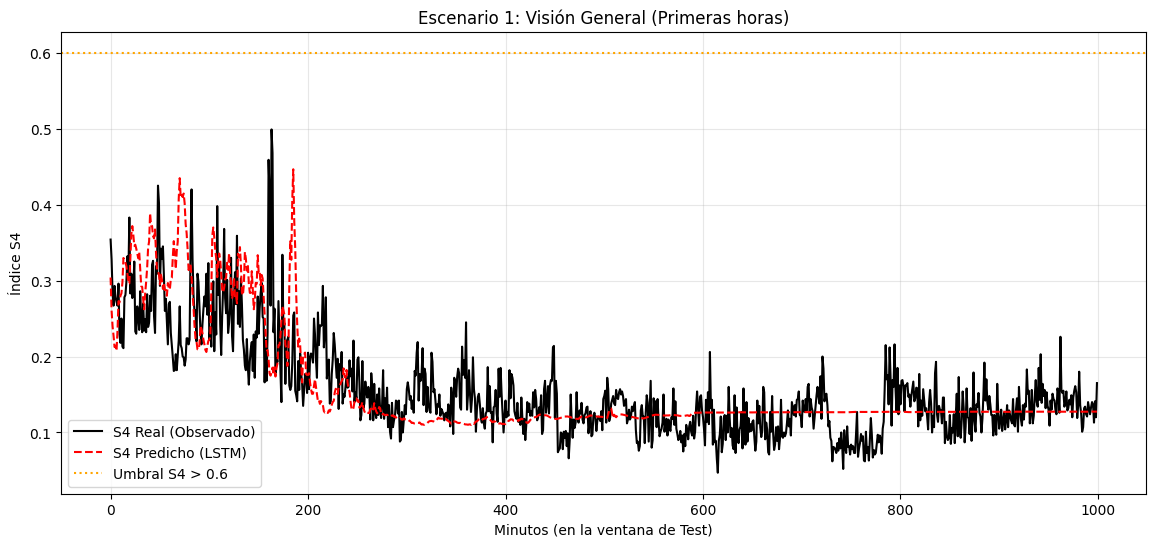


Graficando la tormenta más fuerte encontrada en el índice 1564...


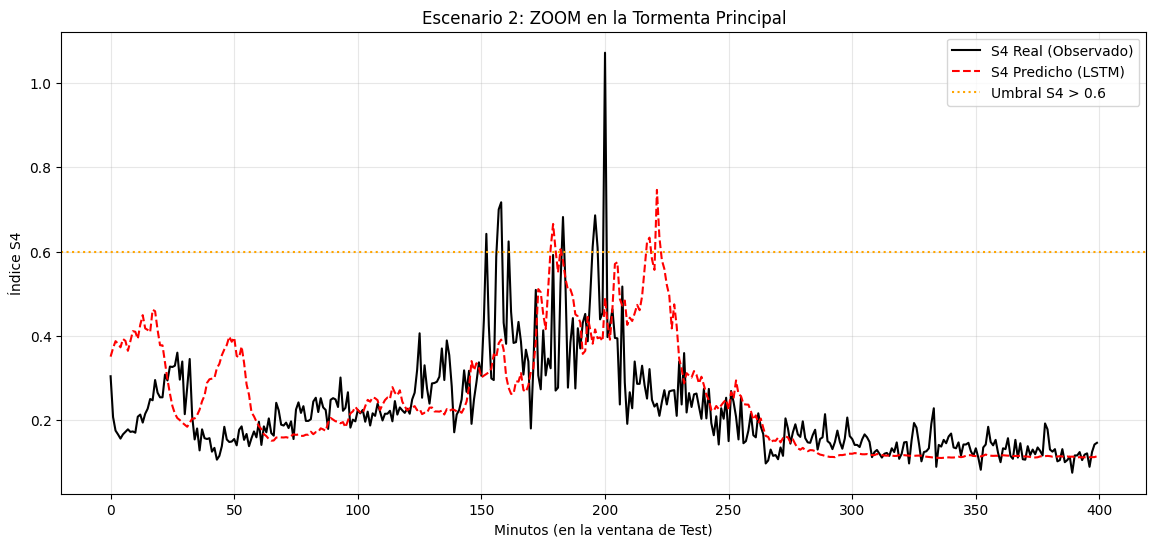

In [50]:
# -----------------------------------------------------------------------------
# A. CÁLCULO DE MÉTRICAS (GENERAL VS TORMENTAS)
# -----------------------------------------------------------------------------
def evaluar_rendimiento(y_true, y_pred, umbral_evento=0.6):
    # 1. Error Global
    rmse_global = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_global = mean_absolute_error(y_true, y_pred)
    
    # 2. Error solo en Eventos (Donde realmente había cintilación)
    mask_eventos = y_true >= umbral_evento
    
    if np.sum(mask_eventos) > 0:
        rmse_eventos = np.sqrt(mean_squared_error(y_true[mask_eventos], y_pred[mask_eventos]))
        mae_eventos = mean_absolute_error(y_true[mask_eventos], y_pred[mask_eventos])
    else:
        rmse_eventos = 0
        mae_eventos = 0
        print("⚠️ No se encontraron eventos > 0.6 en este set de datos.")

    print(f"--- REPORTE DE RENDIMIENTO ---")
    print(f"Global RMSE: {rmse_global:.4f}")
    print(f"Global MAE:  {mae_global:.4f}")
    print(f"-"*30)
    print(f"⚡ ERROR EN TORMENTAS (S4 > {umbral_evento}):")
    print(f"Event RMSE:  {rmse_eventos:.4f}")
    print(f"Event MAE:   {mae_eventos:.4f}")
    
    return rmse_global, rmse_eventos

# Ejecutamos el reporte
evaluar_rendimiento(y_test_real, y_pred_real, umbral_evento=0.6)


# -----------------------------------------------------------------------------
# B. GRÁFICA DE COMPARACIÓN (Zoom en días específicos)
# -----------------------------------------------------------------------------
def graficar_escenario(y_true, y_pred, inicio, fin, titulo="Comparación"):
    plt.figure(figsize=(14, 6))
    
    # Graficamos Real vs Predicho
    plt.plot(y_true[inicio:fin], label='S4 Real (Observado)', color='black', linewidth=1.5)
    plt.plot(y_pred[inicio:fin], label='S4 Predicho (LSTM)', color='red', linestyle='--', linewidth=1.5)
    
    # Línea de umbral de cintilación
    plt.axhline(y=0.6, color='orange', linestyle=':', label='Umbral S4 > 0.6')
    
    plt.title(titulo)
    plt.ylabel('Índice S4')
    plt.xlabel('Minutos (en la ventana de Test)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- ESCENARIOS PARA VISUALIZAR ---

# 1. Ver los primeros 1000 minutos del Test (Visión General)
graficar_escenario(y_test_real, y_pred_real, 0, 1000, "Escenario 1: Visión General (Primeras horas)")

# 2. BUSCAR AUTOMÁTICAMENTE UNA TORMENTA PARA GRAFICAR
# Buscamos el índice donde ocurre el valor máximo en el Test
idx_max_s4 = np.argmax(y_test_real)
start_zoom = max(0, idx_max_s4 - 200) # 200 mins antes del pico
end_zoom = min(len(y_test_real), idx_max_s4 + 200) # 200 mins después

print(f"\nGraficando la tormenta más fuerte encontrada en el índice {idx_max_s4}...")
graficar_escenario(y_test_real, y_pred_real, start_zoom, end_zoom, "Escenario 2: ZOOM en la Tormenta Principal")